<a href="https://colab.research.google.com/github/lax-17/Fmri-to-image/blob/main/StyleGAN2_Generator_with_fMRI_to_W%2B_Mapper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline GAN model for assessment

**Module:** Deep Neural Networks and Learning Systems

In this demonstration and notebook, we will develop a baseline model for your assessment task.


---


**Objectives:**

- Develop the baseline convolutional GAN
- Understand the potential modifications to this model to be performed as an assessment

## Setting up the dataset

The dataset is located in a different drive (public). Therefore, we need to add a shortcut to the data directory in our own drive.

**Original dataset**

Open the dataset external drive: [https://drive.google.com/drive/folders/1DUf3nGNNFk6YjRjQtZPfAY5N105GoGJb](https://drive.google.com/drive/folders/1DUf3nGNNFk6YjRjQtZPfAY5N105GoGJb) and click in add shortcut.


## Utility functions

The following functions can be used to load the FMRI data from a given subject, load activity from a given region of interest or loading the corresponding image.

In [ ]:
import os, glob, joblib, shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
from torchvision.utils import save_image
from sklearn.decomposition import PCA


In [ ]:
root_dir = '/content/drive/MyDrive/Assesment/Dataset'
algonauts_dir = 'algonauts_2023_tutorial_data'

In [ ]:

algonauts_path = os.path.join(root_dir, algonauts_dir)
print(f"Dataset path: {algonauts_path}")
if not os.path.exists(algonauts_path):
    print("Warning: Dataset path does not exist. Please check root_dir and algonauts_dir.")

Dataset path: /content/drive/MyDrive/Assesment/Dataset/algonauts_2023_tutorial_data


## Loading Data


In [ ]:
# @title Helper functions

# Loads all the fmri data associated to a given subject
def load_fmri_of_subject(subj, hemisphere, directory=root_dir):
    # subj: Subject number (e.g., 1)
    # hemisphere: 'left' or 'right'
    subj_str = format(subj, '02') # Format subject number (e.g., 1 -> '01')
    data_dir = os.path.join(directory, algonauts_dir)
    subj_dir = os.path.join(data_dir, 'subj' + subj_str) # e.g., subj01
    fmri_dir = os.path.join(subj_dir, 'training_split', 'training_fmri') # Location of brain activation

    # Load the data based on hemisphere
    if hemisphere.lower() == 'left':
        brain_activity = np.load(os.path.join(fmri_dir, 'lh_training_fmri.npy'))
    elif hemisphere.lower() == 'right':
        brain_activity = np.load(os.path.join(fmri_dir, 'rh_training_fmri.npy'))
    else:
        raise ValueError("Hemisphere must be 'left' or 'right'")
    return brain_activity

# Loads the data associated to a specific part of the brain
def load_fmri_region_of_interest(subj, roi, hemisphere, directory=root_dir):
    subj_str = format(subj, '02')
    data_dir = os.path.join(directory, algonauts_dir)
    subj_dir = os.path.join(data_dir, 'subj' + subj_str) # e.g., subj01

    # Define the ROI class based on the selected ROI
    if roi in ["V1v", "V1d", "V2v", "V2d", "V3v", "V3d", "hV4"]:
        roi_class = 'prf-visualrois'
    elif roi in ["EBA", "FBA-1", "FBA-2", "mTL-bodies"]:
        roi_class = 'floc-bodies'
    elif roi in ["OFA", "FFA-1", "FFA-2", "mTL-faces", "aTL-faces"]:
        roi_class = 'floc-faces'
    elif roi in ["OPA", "PPA", "RSC"]:
        roi_class = 'floc-places'
    elif roi in ["OWFA", "VWFA-1", "VWFA-2", "mfs-words", "mTL-words"]:
        roi_class = 'floc-words'
    elif roi in ["early", "midventral", "midlateral", "midparietal", "ventral", "lateral", "parietal"]:
        roi_class = 'streams'
    else:
        raise ValueError(f"Unknown ROI: {roi}")

    # Loading the roi masks (To locate the activations of a given region)
    roi_mask_file = os.path.join(subj_dir, 'roi_masks', f'{hemisphere[0]}h.{roi_class}_challenge_space.npy')
    roi_map_file = os.path.join(subj_dir, 'roi_masks', f'mapping_{roi_class}.npy')

    if not os.path.exists(roi_mask_file) or not os.path.exists(roi_map_file):
         print(f"Warning: ROI mask or map file not found for subj {subj}, roi {roi}, hemi {hemisphere}")
         # Return empty array or handle appropriately
         # Determine shape based on full fMRI data for consistency
         fmri_full = load_fmri_of_subject(subj, hemisphere, directory)
         return np.zeros((fmri_full.shape[0], 0))


    roi_class_idx = np.load(roi_mask_file)
    roi_map = np.load(roi_map_file, allow_pickle=True).item()
    # Find the key corresponding to the value `roi`
    try:
      roi_mapping_indices = [k for k, v in roi_map.items() if v == roi]
      if not roi_mapping_indices:
          raise ValueError(f"ROI '{roi}' not found in mapping for class '{roi_class}'")
      roi_mapping = roi_mapping_indices[0] # Take the first if multiple (shouldn't happen)
    except ValueError as e:
      print(f"Error finding ROI mapping: {e}")
       # Fallback to empty array if ROI name not in map
      fmri_full = load_fmri_of_subject(subj, hemisphere, directory)
      return np.zeros((fmri_full.shape[0], 0))


    challenge_roi_indices = np.where(roi_class_idx == roi_mapping)[0]
    if len(challenge_roi_indices) == 0:
        # print(f"Warning: No voxels found for ROI '{roi}' in subject {subj}, hemisphere {hemisphere}")
        # Return empty array with correct first dimension
        fmri_full = load_fmri_of_subject(subj, hemisphere, directory)
        return np.zeros((fmri_full.shape[0], 0))


    # Load the full brain activity
    if hemisphere.lower() == 'left':
        fmri_full_path = os.path.join(subj_dir, 'training_split', 'training_fmri', 'lh_training_fmri.npy')
    elif hemisphere.lower() == 'right':
        fmri_full_path = os.path.join(subj_dir, 'training_split', 'training_fmri', 'rh_training_fmri.npy')
    else:
         raise ValueError("Hemisphere must be 'left' or 'right'")

    if not os.path.exists(fmri_full_path):
        raise FileNotFoundError(f"fMRI data file not found: {fmri_full_path}")

    brain_activity = np.load(fmri_full_path)

    # Select the appropriate data for the ROI
    fmri_roi_data = brain_activity[:, challenge_roi_indices]

    return fmri_roi_data


# Load a particular image from a subject
def load_image_subject(subj, img_idx, directory=root_dir):
    subj_str = format(subj, '02')
    data_dir = os.path.join(directory, algonauts_dir)
    subj_dir = os.path.join(data_dir, 'subj' + subj_str) # e.g., subj01
    train_img_dir = os.path.join(subj_dir, 'training_split', 'training_images')

    # Ensure consistent ordering
    try:
        train_img_list = sorted(os.listdir(train_img_dir))
        if img_idx >= len(train_img_list):
            raise IndexError(f"Image index {img_idx} out of bounds for subject {subj}")
        img_file = train_img_list[img_idx]
        img_path = os.path.join(train_img_dir, img_file)
        train_img = Image.open(img_path).convert('RGB') # Image library (PIL)
    except FileNotFoundError:
        print(f"Error: Image directory not found at {train_img_dir}")
        return None
    except IndexError as e:
        print(f"Error: {e}")
        return None
    return train_img

# Helper function to display images (handles normalization)
def showImage(ax, image, title=''):
    ''' Helper function to display PyTorch tensors as images '''
    # Unnormalize if needed (assuming normalization was [0.5]*3, [0.5]*3)
    # Adjust if your normalization was different
    if image.min() < -0.1: # Simple check if likely normalized
         image = image * 0.5 + 0.5
    image = image.clamp(0, 1) # Ensure values are in [0, 1]
    ax.imshow(image.permute(1, 2, 0).cpu().numpy()) # Permute (C, H, W) -> (H, W, C)
    ax.set_title(title)
    ax.axis('off') # Hide axes

# Example usage (optional, for verification)
# try:
#     test_img = load_image_subject(1, 0)
#     fmri_v1v = load_fmri_region_of_interest(1, "V1v", "left")
#     print("Helper functions loaded successfully.")
#     print(f"Test image type: {type(test_img)}")
#     print(f"V1v fMRI data shape: {fmri_v1v.shape}")
# except Exception as e:
#     print(f"Error testing helper functions: {e}")

## Pre-Processing data
## Pre-Processing Data

This section involves several steps:
1.  **Cloning `encoder4editing`:** We need this repository for its StyleGAN2 model implementation and potentially for its pre-trained encoder if we were generating W+ latents from scratch (though we will load pre-computed ones).
2.  **Installing Dependencies:** Necessary Python packages for e4e and StyleGAN2.
3.  **Generating/Loading W+ Latents:** The original images need to be encoded into StyleGAN2's W+ latent space. The original notebook included steps to run e4e's inference script. **This step only needs to be run ONCE.** If you already have the `latents.pt` file, you can skip running the inference script (Cell 16 below). We will load the pre-computed `latents.pt` later.
4.  **Loading fMRI Data for Specific ROIs:** We'll combine data from selected ROIs.
5.  **Applying PCA:** Reduce the dimensionality of the combined fMRI data using Principal Component Analysis (PCA).
6.  **Creating Datasets:** Prepare PyTorch datasets for pairing images with ROI fMRI data and later pairing PCA-reduced fMRI with W+ latents.

In [ ]:
# Change directory to where you want to clone the repo
# e.g., your main project directory in Google Drive
%cd /content/drive/MyDrive/
# Clone only if the directory doesn't exist already
if not os.path.exists('encoder4editing'):
    !git clone https://github.com/omertov/encoder4editing.git
else:
    print("'encoder4editing' directory already exists. Skipping clone.")
# Change into the cloned directory
%cd encoder4editing

/content/drive/MyDrive
'encoder4editing' directory already exists. Skipping clone.
/content/drive/MyDrive/encoder4editing


In [ ]:
# # still in Colab Python
# import os, glob, shutil
# SRC  = '/content/drive/MyDrive/pixel2style2pixel/input_images'  # or wherever you put them
# DST  = '/content/drive/MyDrive/encoder4editing/input_images'
# os.makedirs(DST, exist_ok=True)
# for f in glob.glob(f"{SRC}/*.png"):
#     shutil.copy(f, DST)
# print("→ Copied", len(os.listdir(DST)), "images to", DST)

# %cd /content/drive/MyDrive/encoder4editing
# !mkdir -p inversion_results

# !python scripts/inference.py \
#   --images_dir  input_images \
#   --save_dir    inversion_results \
#   --batch       1 \
#   --latents_only \
#   pretrained_models/e4e_ffhq_encode.pt

In [ ]:
# !pip install torch torchvision pillow tqdm numpy scipy dlib opencv-python-headless lpips

In [ ]:
# Download the pre-trained e4e encoder model (needed only for inference step)
%mkdir -p pretrained_models
!wget --continue \
  "https://huggingface.co/AIRI-Institute/HairFastGAN/resolve/main/pretrained_models/encoder4editing/e4e_ffhq_encode.pt" \
  -O pretrained_models/e4e_ffhq_encode.pt

--2025-04-22 18:46:03--  https://huggingface.co/AIRI-Institute/HairFastGAN/resolve/main/pretrained_models/encoder4editing/e4e_ffhq_encode.pt
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.121, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/1f/69/1f69f965bae41772918d38051f8430e3fc85c7179834610463bcf91ac9c98b16/2ace1d9a8c05c10a399bcd500b8dda118f759ff1aac89dbdab7435f2136a0999?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27e4e_ffhq_encode.pt%3B+filename%3D%22e4e_ffhq_encode.pt%22%3B&Expires=1745351163&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0NTM1MTE2M319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzFmLzY5LzFmNjlmOTY1YmFlNDE3NzI5MThkMzgwNTFmODQzMGUzZmM4NWM3MTc5ODM0NjEwNDYzYmNmOTFhYzljOThiMTYvMmFjZTFkOWE4YzA1YzEwYTM5OWJjZDUwMGI4ZGRhMTE4Zjc1OWZmMWFhYzg

In [ ]:
!ls -lh pretrained_models/e4e_ffhq_encode.pt

-rw------- 1 root root 1.2G Apr 22 14:18 pretrained_models/e4e_ffhq_encode.pt


## Building Datasets for PCA and Training

First, we create a dataset that combines fMRI data from selected Regions of Interest (ROIs) for a specific subject and hemisphere, paired with the corresponding images. This dataset will be used to fit the PCA model.

Then, we will create the final dataset for training our Mapper network, pairing the PCA-reduced fMRI components with the pre-computed W+ latent codes.

## Building a dataset.

First we create a dataset that represents ALL the brain activity. If you want to use a particular region you need to modify this class

### Loading Whole dataset


In [ ]:
class CombinedROIBrainDataset(Dataset):
    def __init__(self, subject, hemisphere, roi_list, transform=None, data_dir=algonauts_path):
        """
        Uses existing loader functions to build (image, fMRI) pairs
        from concatenated ROIs for a specific subject.
        """
        self.subject = subject
        self.hemi = hemisphere
        self.roi_list = roi_list
        self.transform = transform
        self.data_dir = data_dir # Use the path constructed earlier

        # Gather and concatenate ROI-wise fMRI
        print(f"Loading fMRI data for subject {subject}, hemisphere {hemisphere}...")
        roi_data_list = []
        voxel_counts = {}
        for roi in tqdm(roi_list, desc="Loading ROIs"):
            # Use root_dir here as the helper expects the base directory
            data = load_fmri_region_of_interest(subject, roi, hemisphere, directory=root_dir)
            if data.shape[1] > 0: # Only add if ROI data exists
                roi_data_list.append(data)
                voxel_counts[roi] = data.shape[1]
            else:
                print(f"  - Skipping ROI '{roi}' (0 voxels found)")

        if not roi_data_list:
             raise ValueError(f"No voxel data found for any specified ROI for subject {subject}, hemisphere {hemisphere}.")

        self.fmri_data = np.concatenate(roi_data_list, axis=1)
        self.n_images = self.fmri_data.shape[0]
        self.n_voxels = self.fmri_data.shape[1]
        print(f"Concatenated fMRI data shape: ({self.n_images}, {self.n_voxels})")
        print("Voxel counts per ROI:", voxel_counts)


    def __len__(self):
        return self.n_images

    def __getitem__(self, idx):
        # fMRI vector for the image index
        fmri_vec = torch.from_numpy(self.fmri_data[idx]).float()

        # Corresponding image via helper
        # Use root_dir here as the helper expects the base directory
        img = load_image_subject(self.subject, idx, directory=root_dir)
        if img is None:
           # Handle cases where image loading fails
           print(f"Warning: Could not load image at index {idx} for subject {self.subject}")
           # Return a placeholder or raise an error
           # Example: return a zero tensor of expected shape
           c, h, w = 3, 64, 64 # Assuming transform resizes to 64x64
           return torch.zeros((c, h, w)), fmri_vec # Return dummy image tensor

        if self.transform:
            img = self.transform(img)

        return img, fmri_vec

Creating our train loader

### Loading ROIs

In [ ]:
# --- Parameters ---
TARGET_SUBJECT = 1
TARGET_HEMISPHERE = 'left'
# Select ROIs known to have data for subject 1, left hemisphere (adjust as needed)
# Example: Visual areas + Place areas
SELECTED_ROIS = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'OPA', 'PPA', 'RSC']
IMAGE_SIZE = 64 # Target image size for StyleGAN2 input/output

# --- Transforms ---
# For loading images into tensors and normalizing to [-1, 1] range suitable for GANs
img_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3), # Normalize to [-1, 1]
])

# --- Create Dataset for PCA ---
try:
    roi_ds = CombinedROIBrainDataset(
        subject=TARGET_SUBJECT,
        hemisphere=TARGET_HEMISPHERE,
        roi_list=SELECTED_ROIS,
        transform=img_transform,
        data_dir=algonauts_path # Pass the constructed path
    )
    print(f"Successfully created dataset: {len(roi_ds)} samples, {roi_ds.n_voxels} voxels")

    # Quick check on the first item
    img_example, vec_example = roi_ds[0]
    print(f"Example image shape: {img_example.shape}") # Should be [3, IMAGE_SIZE, IMAGE_SIZE]
    print(f"Example fMRI vector shape: {vec_example.shape}") # Should be [n_voxels]

except (ValueError, FileNotFoundError, IndexError) as e:
    print(f"Error creating dataset: {e}")
    print("Please ensure paths are correct and subject/hemisphere/ROIs have data.")
    # Stop execution or handle error appropriately
    roi_ds = None # Set to None if creation failed

Loading fMRI data for subject 1, hemisphere left...


Loading ROIs:   0%|          | 0/10 [00:00<?, ?it/s]

Concatenated fMRI data shape: (9841, 8204)
Voxel counts per ROI: {'V1v': 710, 'V1d': 828, 'V2v': 632, 'V2d': 692, 'V3v': 567, 'V3d': 669, 'hV4': 531, 'OPA': 1863, 'PPA': 1311, 'RSC': 401}
Successfully created dataset: 9841 samples, 8204 voxels
Example image shape: torch.Size([3, 64, 64])
Example fMRI vector shape: torch.Size([8204])


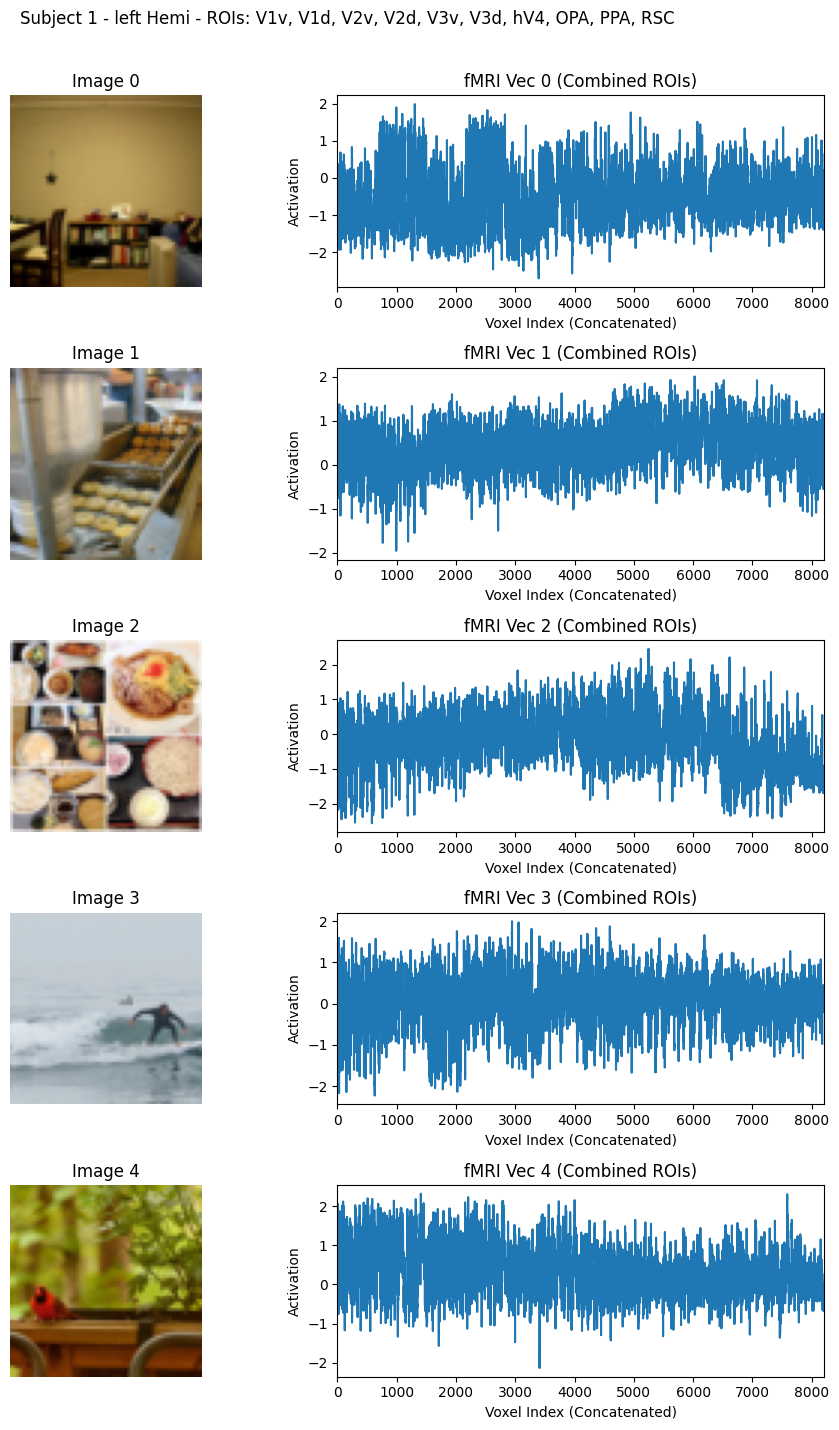

In [ ]:
# Visualize first few samples from the ROI dataset
if roi_ds: # Only run if dataset creation was successful
    num_images_to_display = 5
    fig, axes = plt.subplots(num_images_to_display, 2, figsize=(10, 15))
    fig.suptitle(f'Subject {TARGET_SUBJECT} - {TARGET_HEMISPHERE} Hemi - ROIs: {", ".join(SELECTED_ROIS)}')

    for i in range(num_images_to_display):
        img, fmri_vec = roi_ds[i] # Get data directly from dataset

        # Display the image using the helper function
        showImage(axes[i, 0], img, f'Image {i}')

        # Display the brain activity
        vec_np = fmri_vec.numpy() # Convert tensor to numpy
        axes[i, 1].plot(vec_np)
        axes[i, 1].set_title(f"fMRI Vec {i} (Combined ROIs)")
        axes[i, 1].set_xlabel("Voxel Index (Concatenated)")
        axes[i, 1].set_ylabel("Activation")
        axes[i, 1].set_xlim(0, len(vec_np))


    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("Dataset 'roi_ds' not available for visualization.")

Loading existing PCA model from /content/drive/MyDrive/fmri2gan_pca/pca_256.joblib
Loading existing fMRI latent matrix from /content/drive/MyDrive/fmri2gan_pca/fmri_pca_256.npy
Loaded PCA components shape: (9841, 256)


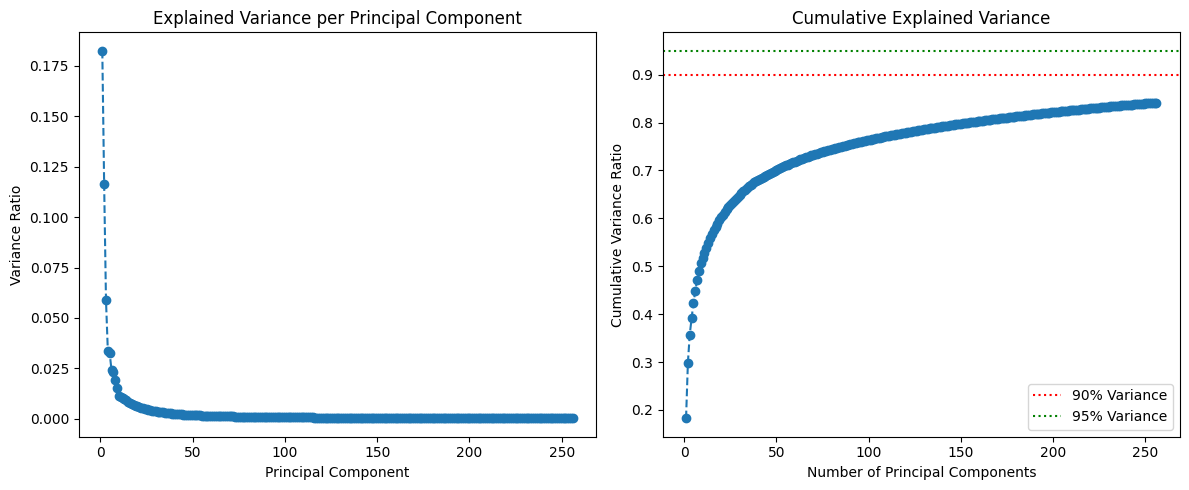

Total variance explained by 256 components: 84.19%


In [ ]:
# --- PCA ---
N_COMPONENTS = 256
PCA_SAVE_DIR = '/content/drive/MyDrive/fmri2gan_pca' # Directory to save/load PCA results
PCA_MODEL_PATH = os.path.join(PCA_SAVE_DIR, f'pca_{N_COMPONENTS}.joblib')
FMRI_LATENT_PATH = os.path.join(PCA_SAVE_DIR, f'fmri_pca_{N_COMPONENTS}.npy')

os.makedirs(PCA_SAVE_DIR, exist_ok=True)

if roi_ds is None:
    print("Error: roi_ds is not available. Cannot perform PCA.")
else:
    # Check if PCA results already exist
    if os.path.exists(PCA_MODEL_PATH) and os.path.exists(FMRI_LATENT_PATH):
        print(f"Loading existing PCA model from {PCA_MODEL_PATH}")
        print(f"Loading existing fMRI latent matrix from {FMRI_LATENT_PATH}")
        pca = joblib.load(PCA_MODEL_PATH)
        fmri_pca_components = np.load(FMRI_LATENT_PATH)
        print(f"Loaded PCA components shape: {fmri_pca_components.shape}")
    else:
        print(f"Fitting PCA ({N_COMPONENTS} components)...")
        # Ensure data is numpy array for PCA
        fmri_data_np = roi_ds.fmri_data
        print(f"Input fMRI data shape for PCA: {fmri_data_np.shape}")

        pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
        fmri_pca_components = pca.fit_transform(fmri_data_np) # -> (n_images, N_COMPONENTS)

        print(f"PCA fitting complete. Output shape: {fmri_pca_components.shape}")
        print(f"Saving PCA model to {PCA_MODEL_PATH}")
        print(f"Saving fMRI latent matrix to {FMRI_LATENT_PATH}")
        joblib.dump(pca, PCA_MODEL_PATH)
        np.save(FMRI_LATENT_PATH, fmri_pca_components)

    # --- Explained Variance Plot ---
    if 'pca' in locals(): # Check if pca object exists
        explained_variance = pca.explained_variance_ratio_
        cumulative_explained_variance = np.cumsum(explained_variance)

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(range(1, N_COMPONENTS + 1), explained_variance, marker='o', linestyle='--')
        plt.title('Explained Variance per Principal Component')
        plt.xlabel('Principal Component')
        plt.ylabel('Variance Ratio')

        plt.subplot(1, 2, 2)
        plt.plot(range(1, N_COMPONENTS + 1), cumulative_explained_variance, marker='o', linestyle='--')
        plt.title('Cumulative Explained Variance')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Variance Ratio')
        plt.axhline(y=0.9, color='r', linestyle=':', label='90% Variance') # Example threshold
        plt.axhline(y=0.95, color='g', linestyle=':', label='95% Variance') # Example threshold
        plt.legend()

        plt.tight_layout()
        plt.show()

        print(f"Total variance explained by {N_COMPONENTS} components: {cumulative_explained_variance[-1]*100:.2f}%")
    else:
        print("PCA object not available for plotting explained variance.")

In [ ]:
# --- Load W+ Latents ---
# These should correspond to the images used in roi_ds (subject 1 in this case)
WPLUS_PATH = '/content/drive/MyDrive/encoder4editing/inversion_results/latents.pt'

if not os.path.exists(WPLUS_PATH):
    print(f"Error: W+ latent file not found at {WPLUS_PATH}")
    print("Please run the e4e inference step (Cell 16) or provide the correct path.")
    wplus_tensor = None
else:
    print(f"Loading W+ latents from {WPLUS_PATH}...")
    # Load to CPU first, ensure float32, then reshape
    wplus_tensor = torch.load(WPLUS_PATH, map_location='cpu').float()
    # Expected shape [N_images, 18, 512] -> Flatten to [N_images, 18*512]
    if wplus_tensor.ndim == 3 and wplus_tensor.shape[1] == 18 and wplus_tensor.shape[2] == 512:
         wplus_flat = wplus_tensor.view(wplus_tensor.shape[0], -1)
         print(f"Loaded and flattened W+ tensor shape: {wplus_flat.shape}")
         # Check consistency with fMRI data
         if fmri_pca_components is not None and fmri_pca_components.shape[0] != wplus_flat.shape[0]:
              print(f"Warning: Mismatch between fMRI samples ({fmri_pca_components.shape[0]}) and W+ samples ({wplus_flat.shape[0]})")
              wplus_tensor = None # Indicate error
         else:
             wplus_tensor = wplus_flat # Assign the flattened tensor
    else:
        print(f"Error: Loaded W+ tensor has unexpected shape {wplus_tensor.shape}. Expected [N, 18, 512].")
        wplus_tensor = None

Loading W+ latents from /content/drive/MyDrive/encoder4editing/inversion_results/latents.pt...


<ipython-input-15-9974d689d420>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wplus_tensor = torch.load(WPLUS_PATH, map_location='cpu').float()


Loaded and flattened W+ tensor shape: torch.Size([9841, 9216])


## Model Definitions

We define:
1.  **StyleGAN2 Generator:** Loaded from a pre-trained checkpoint and frozen (not trained).
2.  **Mapper Network:** An MLP that learns to map fMRI PCA components to the W+ space. This is the trainable part.

In [ ]:
# Install ninja-build
!apt-get update -qq
!apt-get install -y ninja-build

# (Optionally) also install the Python package:
!pip install ninja

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ninja-build is already the newest version (1.10.1-1).
0 upgraded, 0 newly installed, 0 to remove and 121 not upgraded.


In [ ]:
# Clear the PyTorch C++ extension cache to force recompilation
!rm -rf /root/.cache/torch_extensions/
print("PyTorch extension cache cleared.")

PyTorch extension cache cleared.


In [ ]:
# Cell 24: Download and Load StyleGAN2 Generator (With Op Import First)

# --- StyleGAN2 Generator ---
import os
import torch
from huggingface_hub import hf_hub_download
print(f"Current working directory: {os.getcwd()}") # Verify we are in encoder4editing

# --- Explicitly import custom ops first to trigger compilation ---
# This is often necessary for custom C++/CUDA extensions in Colab
try:
    print("Attempting to import custom StyleGAN2 ops (fused_act, upfirdn2d)...")
    from models.stylegan2.op import fused_act
    from models.stylegan2.op import upfirdn2d
    print("Custom ops imported successfully.")
except ImportError as e:
    print(f"ImportError during custom op loading: {e}")
    print("This might indicate a build issue. Ensure 'ninja' is installed (Cell 12).")
    print("If this persists after clearing cache and restarting, there might be a deeper compilation problem.")
    # Depending on the error, you might stop here or try proceeding
    # raise e # Uncomment to stop execution if ops fail to load

# --- Now import the Generator class ---
try:
    from models.stylegan2.model import Generator # From encoder4editing repo
    print("Generator class imported successfully.")
except ImportError as e:
    print(f"Failed to import Generator even after importing ops: {e}")
    print("The compilation of custom ops likely failed.")
    raise e # Stop execution

# --- Define Paths ---
STYLEGAN_CKPT_DIR = '/content/drive/MyDrive/stylegan_ckpts'
STYLEGAN_CKPT_FILENAME = 'stylegan2-ffhq-config-f.pt'
# Construct the full path robustly, accounting for the snapshot directory hash
snapshot_base = os.path.join(STYLEGAN_CKPT_DIR, 'models--ZeqiangLai--StyleGAN2/snapshots')
STYLEGAN_CKPT_PATH = None
if os.path.exists(snapshot_base):
    subdirs = [d for d in os.listdir(snapshot_base) if os.path.isdir(os.path.join(snapshot_base, d))]
    if subdirs:
        # Usually there's just one snapshot hash directory
        STYLEGAN_CKPT_PATH = os.path.join(snapshot_base, subdirs[0], STYLEGAN_CKPT_FILENAME)

# --- Download if necessary ---
if not STYLEGAN_CKPT_PATH or not os.path.exists(STYLEGAN_CKPT_PATH):
    print("Downloading StyleGAN2 checkpoint...")
    try:
        # hf_hub_download returns the absolute path
        STYLEGAN_CKPT_PATH = hf_hub_download(
            repo_id='ZeqiangLai--StyleGAN2',
            filename=STYLEGAN_CKPT_FILENAME,
            cache_dir=STYLEGAN_CKPT_DIR # Let hub manage caching within this dir
        )
        print(f"Downloaded checkpoint path: {STYLEGAN_CKPT_PATH}")
    except Exception as download_error:
        print(f"Error downloading checkpoint: {download_error}")
        STYLEGAN_CKPT_PATH = None # Indicate failure
else:
    print(f"Using cached StyleGAN2 checkpoint at: {STYLEGAN_CKPT_PATH}")


# --- Load Generator ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

G = None # Initialize G to None
if STYLEGAN_CKPT_PATH and os.path.exists(STYLEGAN_CKPT_PATH):
    try:
        # Instantiate the generator
        G = Generator(size=1024, style_dim=512, n_mlp=8).to(device)
        print("Loading StyleGAN2 state dict...")
        ckpt = torch.load(STYLEGAN_CKPT_PATH, map_location=device)
        G.load_state_dict(ckpt['g_ema'], strict=False)
        G.eval()
        for p in G.parameters():
            p.requires_grad = False
        print("StyleGAN2 Generator loaded successfully.")
    except Exception as e:
        print(f"Error loading StyleGAN2 Generator state dict: {e}")
        print("Ensure the Generator class and checkpoint are compatible.")
        G = None
else:
    print("StyleGAN2 Checkpoint path is invalid or file doesn't exist. Cannot load generator.")

Current working directory: /content/drive/MyDrive/encoder4editing
Attempting to import custom StyleGAN2 ops (fused_act, upfirdn2d)...


/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Custom ops imported successfully.
Generator class imported successfully.
Using cached StyleGAN2 checkpoint at: /content/drive/MyDrive/stylegan_ckpts/models--ZeqiangLai--StyleGAN2/snapshots/bb4e00dc8ac0afbb9e0a5b6f72754c679673ee2e/stylegan2-ffhq-config-f.pt
Using device: cuda
Loading StyleGAN2 state dict...


<ipython-input-18-8b36a595257f>:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(STYLEGAN_CKPT_PATH, map_location=device)


StyleGAN2 Generator loaded successfully.


In [ ]:
# --- StyleGAN2 Generator ---
from models.stylegan2.model import Generator # From encoder4editing repo

STYLEGAN_CKPT_DIR = '/content/drive/MyDrive/stylegan_ckpts'
STYLEGAN_CKPT_FILENAME = 'stylegan2-ffhq-config-f.pt'
STYLEGAN_CKPT_PATH = os.path.join(STYLEGAN_CKPT_DIR, 'models--ZeqiangLai--StyleGAN2/snapshots/bb4e00dc8ac0afbb9e0a5b6f72754c679673ee2e', STYLEGAN_CKPT_FILENAME)

# Download if necessary (using huggingface_hub ensures it's cached)
if not os.path.exists(STYLEGAN_CKPT_PATH):
    print("Downloading StyleGAN2 checkpoint...")
    from huggingface_hub import hf_hub_download
    STYLEGAN_CKPT_PATH = hf_hub_download(
        repo_id='ZeqiangLai/StyleGAN2',
        filename=STYLEGAN_CKPT_FILENAME,
        cache_dir=STYLEGAN_CKPT_DIR
    )
else:
    print("Using cached StyleGAN2 checkpoint.")

print(f"StyleGAN2 Checkpoint path: {STYLEGAN_CKPT_PATH}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

try:
    # Instantiate the generator (adjust size if using different images, e.g., 1024 for config-f default)
    # For 64x64 images, need to ensure Generator class supports this or adjust parameters.
    # The Generator class from e4e's model.py seems hardcoded for 1024.
    # Let's assume IMAGE_SIZE=64 requires adjustment or a different Generator source.
    # FOR NOW: We'll load the 1024 generator but acknowledge this mismatch.
    # A proper solution might involve finding/adapting a 64x64 StyleGAN2 generator.
    G = Generator(size=1024, style_dim=512, n_mlp=8).to(device) # NOTE: size=1024 might be wrong for 64x64 output goal
    ckpt = torch.load(STYLEGAN_CKPT_PATH, map_location=device)
    G.load_state_dict(ckpt['g_ema'], strict=False) # Use strict=False potentially due to size mismatch
    G.eval()
    for p in G.parameters():
        p.requires_grad = False
    print("StyleGAN2 Generator loaded successfully.")
except Exception as e:
    print(f"Error loading StyleGAN2 Generator: {e}")
    print("Ensure the Generator class and checkpoint are compatible with your target image size.")
    G = None

Using cached StyleGAN2 checkpoint.
StyleGAN2 Checkpoint path: /content/drive/MyDrive/stylegan_ckpts/models--ZeqiangLai--StyleGAN2/snapshots/bb4e00dc8ac0afbb9e0a5b6f72754c679673ee2e/stylegan2-ffhq-config-f.pt
Using device: cuda
StyleGAN2 Generator loaded successfully.


<ipython-input-19-09ebabc7a141>:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(STYLEGAN_CKPT_PATH, map_location=device)


In [ ]:
# --- Mapper Network ---
class Mapper(nn.Module):
    def __init__(self, in_dim=N_COMPONENTS, out_dim=18*512): # Use N_COMPONENTS
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True), # Added inplace=True
            nn.Linear(1024, 2048),
            nn.LeakyReLU(0.2, inplace=True), # Added inplace=True
            nn.Linear(2048, out_dim)
            # Consider adding LayerNorm or Dropout if overfitting occurs
        )
    def forward(self, x):
        return self.net(x)

# Instantiate mapper
mapper = Mapper().to(device)
print("Mapper network defined.")
print(mapper)

Mapper network defined.
Mapper(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1024, out_features=2048, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=2048, out_features=9216, bias=True)
  )
)


In [ ]:
# --- Prepare Final Dataset for Training ---

if fmri_pca_components is not None and wplus_tensor is not None:
    print("Preparing dataset for mapper training...")

    mu_wplus = wplus_tensor.mean(0, keepdim=True)
    std_wplus = wplus_tensor.std(0, keepdim=True)
    std_wplus = std_wplus + 1e-6
    print(f"W+ mean shape: {mu_wplus.shape}, std shape: {std_wplus.shape}")

    wplus_normalized = (wplus_tensor - mu_wplus) / std_wplus
    print(f"Normalized W+ shape: {wplus_normalized.shape}")
    class FMRI2StyleGANDataset(Dataset):
        def __init__(self, fmri_pca_comps, wplus_norm_codes):
            self.x = torch.from_numpy(fmri_pca_comps).float()
            self.y = wplus_norm_codes.float()
            print(f"Dataset X (fMRI PCA) shape: {self.x.shape}, dtype: {self.x.dtype}")
            print(f"Dataset Y (W+ Norm) shape: {self.y.shape}, dtype: {self.y.dtype}")

        def __len__(self):
            return len(self.x)

        def __getitem__(self, i):
            return self.x[i], self.y[i]

    paired_ds_train = FMRI2StyleGANDataset(fmri_pca_components, wplus_normalized)

    BATCH_SIZE = 8
    train_loader = DataLoader(paired_ds_train,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=2,
                              pin_memory=True)

    print(f"DataLoader created with batch size {BATCH_SIZE}.")

    mu_wplus_dev = mu_wplus.to(device)
    std_wplus_dev = std_wplus.to(device)

else:
    print("Error: Cannot create training dataset. fMRI PCA components or W+ tensor is missing.")
    train_loader = None
    mu_wplus_dev = None
    std_wplus_dev = None

Preparing dataset for mapper training...
W+ mean shape: torch.Size([1, 9216]), std shape: torch.Size([1, 9216])
Normalized W+ shape: torch.Size([9841, 9216])
Dataset X (fMRI PCA) shape: torch.Size([9841, 256]), dtype: torch.float32
Dataset Y (W+ Norm) shape: torch.Size([9841, 9216]), dtype: torch.float32
DataLoader created with batch size 8.


In [ ]:
if train_loader and mapper and G and mu_wplus_dev is not None:
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PREVIEW_EVERY = 5
    PREVIEW_IDX = 0
    CHECKPOINT_EVERY = 10

    PREVIEW_DIR = '/content/drive/MyDrive/fmri2gan_previews'
    CHECKPOINT_DIR = '/content/drive/MyDrive/fmri2gan_checkpoints'
    LOSS_CURVE_PATH = '/content/drive/MyDrive/fmri2gan_losses.npy'

    os.makedirs(PREVIEW_DIR, exist_ok=True)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    optimizer = optim.Adam(mapper.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()
    scaler = GradScaler()

    loss_curve = []
    print("Training setup complete.")
    ready_to_train = True
else:
    print("Error: Cannot proceed with training setup. Check previous cells for errors.")
    ready_to_train = False

Training setup complete.


<ipython-input-22-30181daadde1>:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For mixed precision training


Starting training...


Epoch 1/50:   0%|          | 0/1231 [00:00<?, ?it/s]

<ipython-input-23-1725ce54b88f>:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Removed device_type='cuda' for broader compatibility


Epoch 01/50 | Average MSE Loss: 1.027088


Epoch 2/50:   0%|          | 0/1231 [00:00<?, ?it/s]

...

Epoch 04/50 | Average MSE Loss: 0.786521


Epoch 5/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 05/50 | Average MSE Loss: 0.744543


<ipython-input-23-1725ce54b88f>:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0005.png


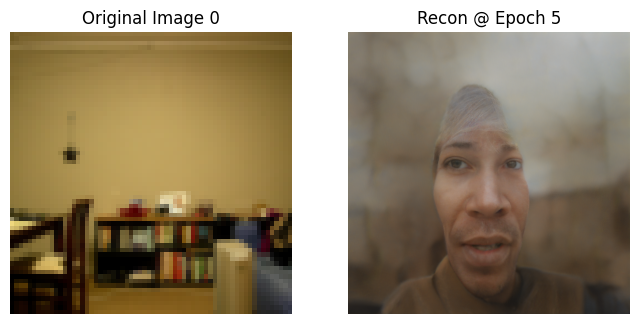

Epoch 6/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 06/50 | Average MSE Loss: 0.699777


Epoch 7/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 07/50 | Average MSE Loss: 0.655829


Epoch 8/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 08/50 | Average MSE Loss: 0.616658


Epoch 9/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 09/50 | Average MSE Loss: 0.579583


Epoch 10/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 10/50 | Average MSE Loss: 0.548175
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0010.png


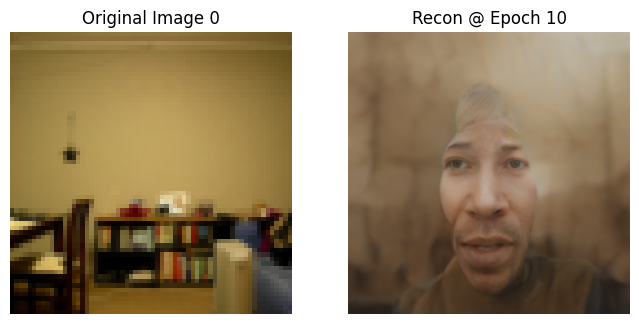

💾 Checkpoint saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_epoch_0010.pt


Epoch 11/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 11/50 | Average MSE Loss: 0.520912


Epoch 12/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 12/50 | Average MSE Loss: 0.494900


...

Epoch 13/50 | Average MSE Loss: 0.472774


Epoch 14/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 14/50 | Average MSE Loss: 0.452334


Epoch 15/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 15/50 | Average MSE Loss: 0.433116
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0015.png


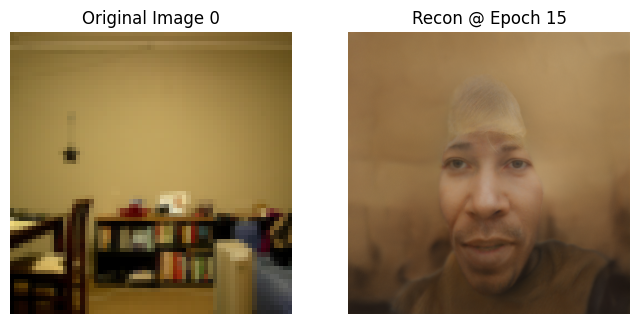

Epoch 16/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 16/50 | Average MSE Loss: 0.415999


Epoch 17/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 17/50 | Average MSE Loss: 0.400698


Epoch 18/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 18/50 | Average MSE Loss: 0.385908


Epoch 19/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 19/50 | Average MSE Loss: 0.372708


Epoch 20/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 20/50 | Average MSE Loss: 0.360610
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0020.png


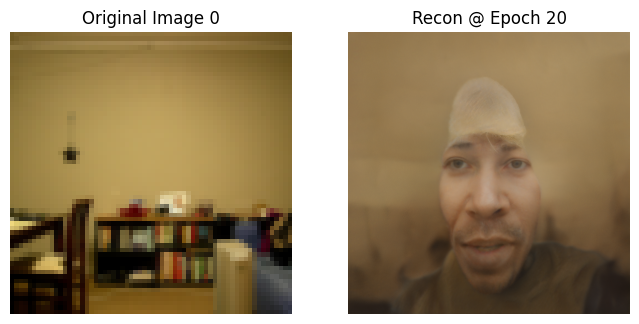

💾 Checkpoint saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_epoch_0020.pt


Epoch 21/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 21/50 | Average MSE Loss: 0.349632


Epoch 22/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 22/50 | Average MSE Loss: 0.339317


...

Epoch 23/50 | Average MSE Loss: 0.329726


Epoch 24/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 24/50 | Average MSE Loss: 0.320924


Epoch 25/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 25/50 | Average MSE Loss: 0.312499
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0025.png


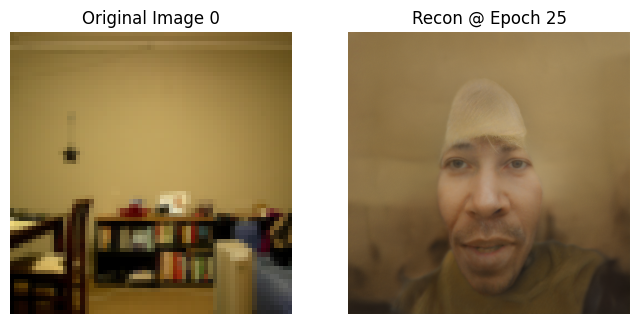

Epoch 26/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 26/50 | Average MSE Loss: 0.305377


Epoch 27/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 27/50 | Average MSE Loss: 0.297903


Epoch 28/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 28/50 | Average MSE Loss: 0.291032


Epoch 29/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 29/50 | Average MSE Loss: 0.285180


Epoch 30/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 30/50 | Average MSE Loss: 0.279642
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0030.png


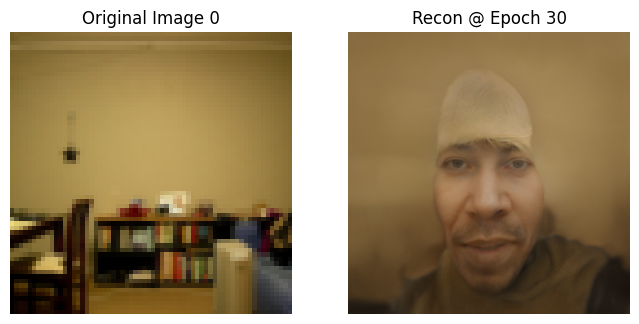

💾 Checkpoint saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_epoch_0030.pt


Epoch 31/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 31/50 | Average MSE Loss: 0.274185


Epoch 32/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 32/50 | Average MSE Loss: 0.269227


...

Epoch 33/50 | Average MSE Loss: 0.264230


Epoch 34/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 34/50 | Average MSE Loss: 0.259929


Epoch 35/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 35/50 | Average MSE Loss: 0.255682
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0035.png


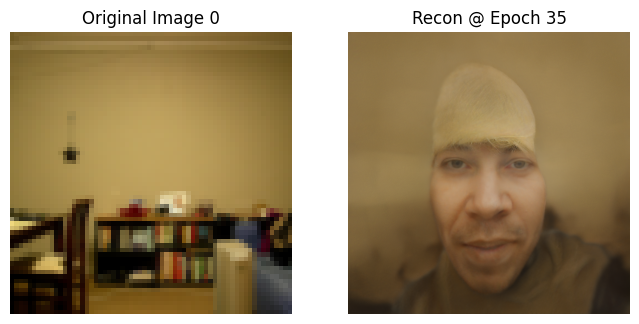

Epoch 36/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 36/50 | Average MSE Loss: 0.251680


Epoch 37/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 37/50 | Average MSE Loss: 0.247861


Epoch 38/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 38/50 | Average MSE Loss: 0.244227


Epoch 39/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 39/50 | Average MSE Loss: 0.241110


Epoch 40/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 40/50 | Average MSE Loss: 0.238210
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0040.png


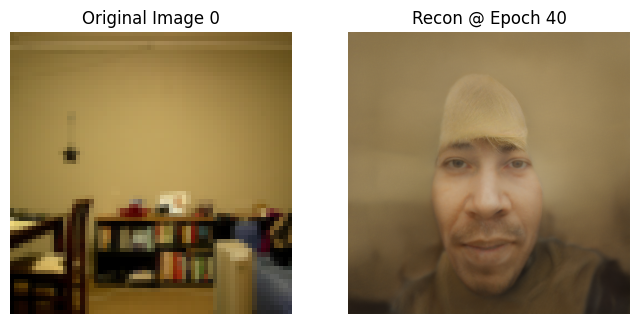

💾 Checkpoint saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_epoch_0040.pt


Epoch 41/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 41/50 | Average MSE Loss: 0.234935


Epoch 42/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 42/50 | Average MSE Loss: 0.232269


...

Epoch 43/50 | Average MSE Loss: 0.229360


Epoch 44/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 44/50 | Average MSE Loss: 0.226925


Epoch 45/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 45/50 | Average MSE Loss: 0.224524
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0045.png


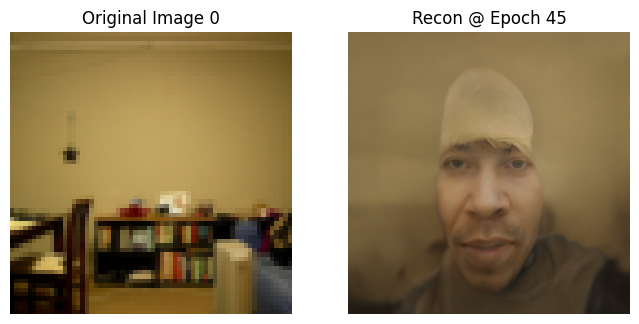

Epoch 46/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 46/50 | Average MSE Loss: 0.221897


Epoch 47/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 47/50 | Average MSE Loss: 0.219823


Epoch 48/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 48/50 | Average MSE Loss: 0.217788


Epoch 49/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 49/50 | Average MSE Loss: 0.215932


Epoch 50/50:   0%|          | 0/1231 [00:00<?, ?it/s]

Epoch 50/50 | Average MSE Loss: 0.213490
🖼️ Reconstructed preview saved to: /content/drive/MyDrive/fmri2gan_previews/recon_epoch_0050.png


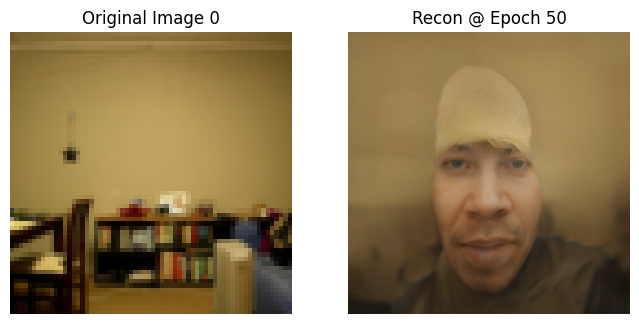

💾 Checkpoint saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_epoch_0050.pt
✅ Training complete. Final model saved to: /content/drive/MyDrive/fmri2gan_checkpoints/mapper_final.pt
📉 Loss curve saved to: /content/drive/MyDrive/fmri2gan_losses.npy


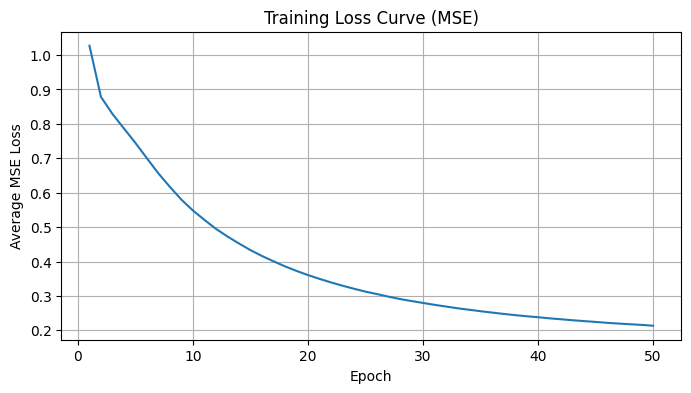

In [ ]:
if ready_to_train:
    print("Starting training...")
    for epoch in range(1, NUM_EPOCHS + 1):
        mapper.train()
        running_loss = 0.0

        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}/{NUM_EPOCHS}")

        for i, (fmri_batch, w_norm_batch) in progress_bar:
            fmri_batch = fmri_batch.to(device)
            w_norm_batch = w_norm_batch.to(device)
            optimizer.zero_grad()
            with autocast():
                w_pred_norm = (mapper(fmri_batch) - mu_wplus_dev) / std_wplus_dev
                loss = criterion(w_pred_norm, w_norm_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': running_loss / (i + 1)})

        avg_epoch_loss = running_loss / len(train_loader)
        loss_curve.append(avg_epoch_loss)
        print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Average MSE Loss: {avg_epoch_loss:.6f}')

        if epoch % PREVIEW_EVERY == 0 or epoch == NUM_EPOCHS:
            mapper.eval()
            with torch.no_grad():
                fmri_preview_vec = paired_ds_train.x[PREVIEW_IDX].unsqueeze(0).to(device)
                with autocast():
                     w_pred_norm_preview = (mapper(fmri_preview_vec) - mu_wplus_dev) / std_wplus_dev
                     w_pred_denorm = (w_pred_norm_preview * std_wplus_dev) + mu_wplus_dev
                w_gan_input = w_pred_denorm.view(1, 18, 512).float()
                img_reconstructed, _ = G([w_gan_input], input_is_latent=True, randomize_noise=False)
                img_reconstructed = (img_reconstructed.clamp(-1, 1) + 1) / 2 # Map to [0, 1]
                img_reconstructed = img_reconstructed.float() # Ensure float32

                img_original_tensor, _ = roi_ds[PREVIEW_IDX]
                img_original_display = (img_original_tensor * 0.5 + 0.5).clamp(0, 1)

            save_path = os.path.join(PREVIEW_DIR, f'recon_epoch_{epoch:04d}.png')
            save_image(img_reconstructed, save_path)
            print(f'🖼️ Reconstructed preview saved to: {save_path}')

            fig, axes = plt.subplots(1, 2, figsize=(8, 4)) # Create 1 row, 2 columns

            axes[0].imshow(img_original_display.permute(1, 2, 0).numpy()) # Display original
            axes[0].set_title(f"Original Image {PREVIEW_IDX}")
            axes[0].axis('off')

            axes[1].imshow(img_reconstructed[0].cpu().permute(1, 2, 0).numpy()) # Display reconstructed
            axes[1].set_title(f"Recon @ Epoch {epoch}")
            axes[1].axis('off')

            plt.show()

        # Save Checkpoint
        if epoch % CHECKPOINT_EVERY == 0 or epoch == NUM_EPOCHS:
             ckpt_path = os.path.join(CHECKPOINT_DIR, f'mapper_epoch_{epoch:04d}.pt')
             torch.save({
                 'epoch': epoch,
                 'mapper_state_dict': mapper.state_dict(),
                 'optimizer_state_dict': optimizer.state_dict(),
                 'loss': avg_epoch_loss,
                 'wplus_mean': mu_wplus.cpu(), # Save stats on CPU
                 'wplus_std': std_wplus.cpu()
             }, ckpt_path)
             print(f'💾 Checkpoint saved to: {ckpt_path}')


    # Save final model separately
    FINAL_CKPT_PATH = os.path.join(CHECKPOINT_DIR, 'mapper_final.pt')
    torch.save({
        'epoch': NUM_EPOCHS,
        'mapper_state_dict': mapper.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss_curve[-1] if loss_curve else None,
        'wplus_mean': mu_wplus.cpu(),
        'wplus_std': std_wplus.cpu()
    }, FINAL_CKPT_PATH)
    print(f'✅ Training complete. Final model saved to: {FINAL_CKPT_PATH}')

    # Save loss curve
    np.save(LOSS_CURVE_PATH, np.array(loss_curve))
    print(f'📉 Loss curve saved to: {LOSS_CURVE_PATH}')

    # Plot loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, NUM_EPOCHS + 1), loss_curve)
    plt.title('Training Loss Curve (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Average MSE Loss')
    plt.grid(True)
    plt.show()

else:
    print("Skipping training loop due to setup errors.")

<ipython-input-26-b4bcc5b293b1>:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


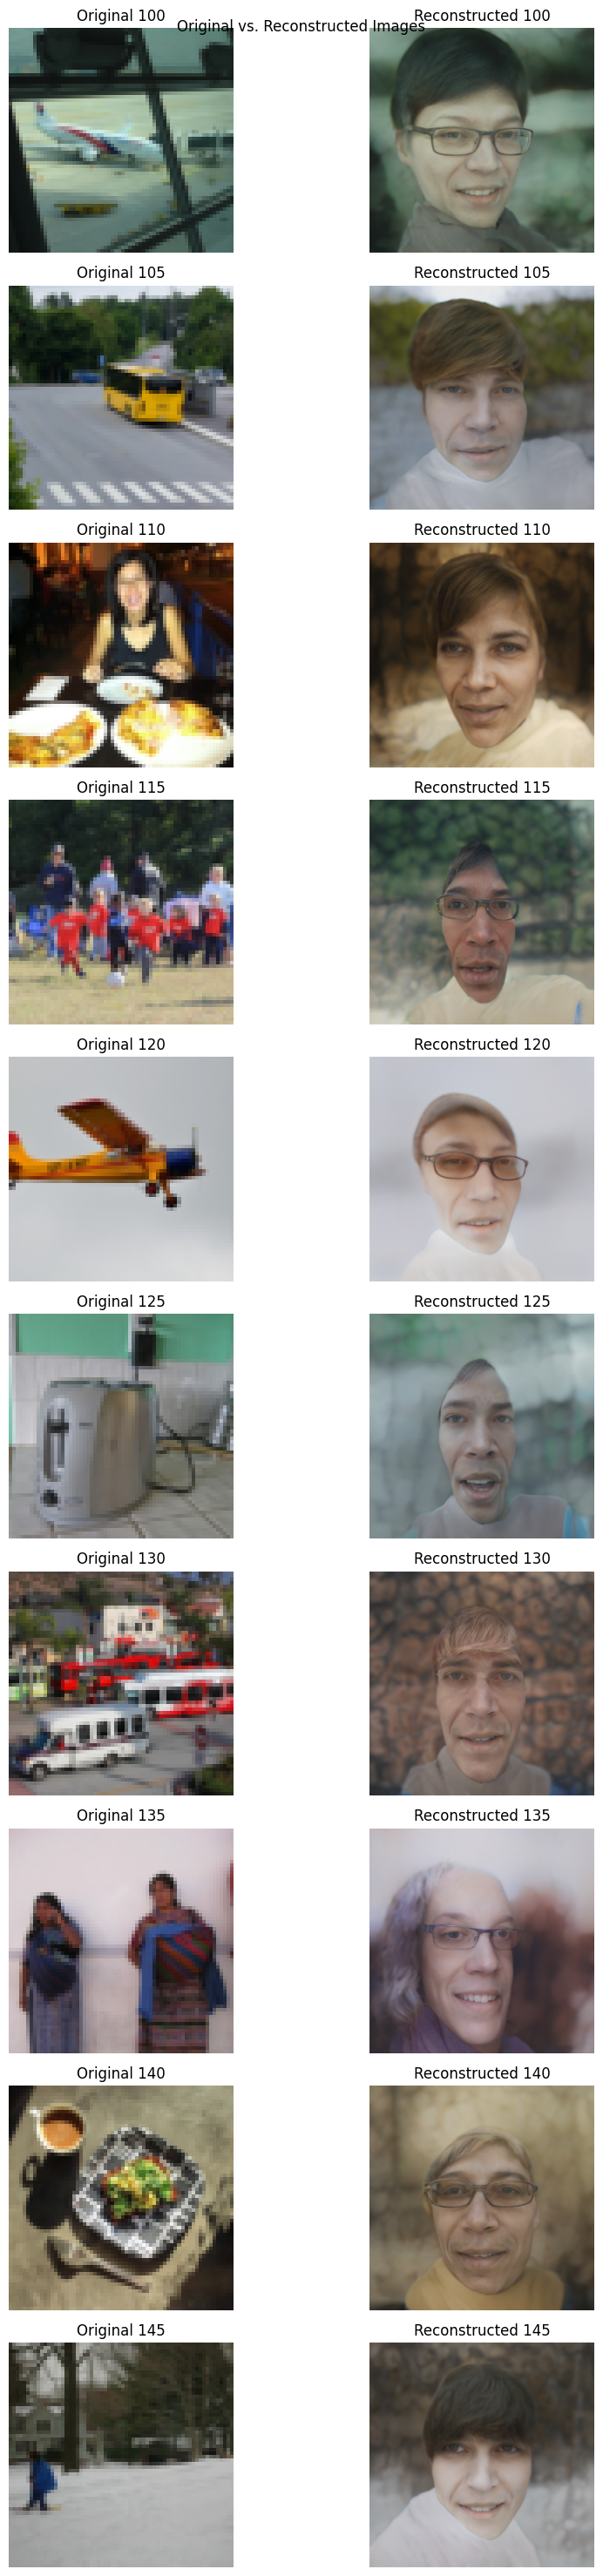

In [ ]:
num_samples_to_display = 10
sample_indices = [100, 105, 110, 115, 120, 125, 130, 135, 140, 145]

if paired_ds_train and mapper and G and mu_wplus_dev is not None:
    mapper.eval()

    fig, axes = plt.subplots(num_samples_to_display, 2, figsize=(10, num_samples_to_display * 3))
    fig.suptitle("Original vs. Reconstructed Images")

    for i, sample_idx in enumerate(sample_indices):
        fmri_input = paired_ds_train.x[sample_idx].unsqueeze(0).to(device)

        with torch.no_grad():
            with autocast():
                w_pred_norm = (mapper(fmri_input) - mu_wplus_dev) / std_wplus_dev
                w_pred_denorm = (w_pred_norm * std_wplus_dev) + mu_wplus_dev

        w_gan_input = w_pred_denorm.view(1, 18, 512).float()


        with torch.no_grad():
            img_reconstructed, _ = G([w_gan_input], input_is_latent=True, randomize_noise=False)
            img_reconstructed = (img_reconstructed.clamp(-1, 1) + 1) / 2
            img_reconstructed = img_reconstructed.float()


        img_original, _ = roi_ds[sample_idx]
        img_original_display = (img_original * 0.5 + 0.5).clamp(0, 1)


        axes[i, 0].imshow(img_original_display.permute(1, 2, 0).cpu().numpy())
        axes[i, 0].set_title(f"Original {sample_idx}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_reconstructed[0].cpu().permute(1, 2, 0).numpy())
        axes[i, 1].set_title(f"Reconstructed {sample_idx}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Cannot run reconstruction example due to missing components.")